# 02 — Task time estimation (models.md §2)

Three LightGBM quantile regressors (p10 / p50 / p90) on `log1p(actual_duration_min)`, explained
with SHAP on the p50 model. Trained on the full 90-day synthetic run (`data/output/*.csv`).

* Split by time: days 1–70 train, 71–80 validation, 81–90 test (by `task_date`).
* Only `completed` tasks with an `actual_duration_min` are targets. Cancelled tasks drop out, and
  so do `delayed` tasks: in this data they are the ones still running at shift end and have no duration.
  Completed tasks that carry a `delay_reason` (the random +15–60 min delays) are kept.
* `operators.personality` and `data/output/truth/` are **never** read. The operator's hidden pace
  can only reach the model through `operator_avg_time_ratio`, computed from their past tasks.
* Feature code lives in `ml/inference/task_time.py`, so notebook and backend compute exactly the
  same thing.

In [1]:
import json, sys, warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

ROOT = Path.cwd().resolve()
while not (ROOT / "CLAUDE.md").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import ml.inference.task_time as T
from ml.inference.task_time import (CATEGORICAL, FEATURE_COLUMNS, QUANTILES, baseline_minutes,
                                    build_feature_table, calibrate, fit_baseline, fit_reference,
                                    reference_minutes, to_model_frame)

DATA = ROOT / "data" / "output"
ART = ROOT / "ml" / "artifacts" / "task_time"
ART.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
START = pd.Timestamp("2026-06-01")
TARGET_COVERAGE = 0.80
LGBM_PARAMS = dict(objective="quantile", n_estimators=600, learning_rate=0.05, num_leaves=31,
                   min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                   reg_lambda=1.0, random_state=RANDOM_STATE, verbose=-1)
EARLY_STOPPING = 50
warnings.filterwarnings("ignore", category=lgb.basic.LGBMDeprecationWarning)
pd.set_option("display.width", 160)

C:\Users\ARYA PAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Data

In [2]:
read = lambda name, dates=(): pd.read_csv(DATA / f"{name}.csv", parse_dates=list(dates))
tasks = read("tasks", ["scheduled_start", "actual_start", "actual_end"])
weather = read("weather", ["ts"])
operators = read("operators").drop(columns=["personality"])   # hidden, never a feature
machines = read("machines")
shifts = read("shifts", ["start_time", "end_time"])
fatigue_log = read("fatigue_log", ["ts"])
maintenance_log = read("maintenance_log", ["event_date"])

day = (pd.to_datetime(tasks.task_date) - START).dt.days + 1
tasks["split"] = np.select([day <= 70, day <= 80], ["train", "val"], "test")
print(pd.crosstab(tasks.status, tasks.actual_duration_min.notna().rename("has_duration")))
print("completed tasks with a delay_reason:",
      (tasks.status.eq("completed") & tasks.delay_reason.notna()).sum())

has_duration  False  True 
status                    
cancelled       200      0
completed         0   6379
delayed         634      0
completed tasks with a delay_reason: 295


## 2 — Feature table

`build_feature_table` joins each task to the weather row of the hour containing its scheduled
start (per site), the operator and machine attributes, the shift (`shift_type`, `hours_into_shift`)
and `day_of_week`. It also adds:

* `health_score`: service-based machine health at shift start, rebuilt from `maintenance_log`
  (hours since the last scheduled service ÷ interval). The drift part of the generator's health
  depends on a future failure, so it is not observable and not used.
* `operator_fatigue_hour_avg`: the operator's mean `fatigue_score` in that hour of shift, over
  their **earlier** shifts (models.md §2 input, "if available").
* `operator_avg_time_ratio`: mean of actual ÷ reference minutes over the operator's tasks of the
  same `task_type` that **ended before this task's scheduled start**, over the last 30 days.

Both yardsticks are fitted on training tasks only. The **baseline** (median minutes per unit ×
quantity, per task_type) is the benchmark from models.md §2. The **reference** is the same except
that haul work is measured in ton-km: haul time scales with distance, so without it an operator's
pace on haul would mostly reflect which distances they happened to drive.

In [3]:
done = tasks[(tasks.status != "cancelled") & tasks.actual_duration_min.notna()]
baseline = fit_baseline(done[done.split == "train"])
reference = fit_reference(done[done.split == "train"])
print("baseline ", {k: round(v, 3) for k, v in baseline.items()}, "min per unit")
print("reference", {k: round(v, 3) for k, v in reference.items()}, "min per unit (haul: per ton-km)")

ft = build_feature_table(tasks, weather, operators, machines, shifts, fatigue_log,
                         maintenance_log, reference)
ft = ft.merge(tasks[["task_id", "split", "delay_reason"]], on="task_id")
ft = ft[(ft.status != "cancelled") & ft.actual_duration_min.notna()].reset_index(drop=True)
print(ft.shape, ft.split.value_counts().to_dict())
print("share missing:", ft[FEATURE_COLUMNS].isna().mean().loc[lambda s: s > 0].round(3).to_dict())

baseline  {'backfill': 0.495, 'dig': 0.632, 'grade': 0.788, 'haul': 1.424, 'load': 0.418, 'trench': 1.14} min per unit
reference {'backfill': 0.495, 'dig': 0.632, 'grade': 0.788, 'haul': 0.99, 'load': 0.418, 'trench': 1.14} min per unit (haul: per ton-km)


(6379, 33) {'train': 4946, 'val': 717, 'test': 716}
share missing: {'haul_distance_m': 0.83, 'operator_avg_time_ratio': 0.02, 'operator_fatigue_hour_avg': 0.014}


**Leakage check.** Recompute `operator_avg_time_ratio` by brute force for 300 random tasks, using only tasks that ended before the scheduled start.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
hist = done.assign(ratio=done.actual_duration_min / reference_minutes(done, reference))
mism = 0
for i in rng.choice(len(ft), 300, replace=False):
    r = ft.iloc[i]
    h = hist[(hist.operator_id == r.operator_id) & (hist.task_type == r.task_type)
             & (hist.actual_end < r.scheduled_start)
             & (hist.actual_end >= r.scheduled_start - T.RATIO_WINDOW)]
    exp = h.ratio.mean() if len(h) else np.nan
    same = np.isclose(exp, r.operator_avg_time_ratio) or (np.isnan(exp) and np.isnan(r.operator_avg_time_ratio))
    mism += not same
    assert r.task_id not in set(h.task_id)
print("mismatches:", mism)
assert mism == 0

# weather join: the joined row is the latest one at or before the scheduled start
r = ft.sample(1, random_state=RANDOM_STATE).iloc[0]
ws = weather[(weather.site_id == r.site_id) & (weather.ts <= r.scheduled_start)].sort_values("ts").iloc[-1]
assert np.isclose(ws.rain_mm, r.rain_mm) and np.isclose(ws.temp_c, r.temp_c)

mismatches: 0


In [5]:
categories = {c: sorted(ft.loc[ft.split == "train", c].dropna().astype(str).unique()) for c in CATEGORICAL}
parts = {s: ft[ft.split == s].reset_index(drop=True) for s in ["train", "val", "test"]}
X = {s: to_model_frame(d, categories) for s, d in parts.items()}
y = {s: np.log1p(d.actual_duration_min.to_numpy()) for s, d in parts.items()}
actual = {s: d.actual_duration_min.to_numpy() for s, d in parts.items()}
{s: len(v) for s, v in y.items()}

{'train': 4946, 'val': 717, 'test': 716}

## 3 — Baseline: median minutes per unit for the task type × quantity

In [6]:
def scores(pred, act):
    return {"mae_min": float(np.mean(np.abs(pred - act))),
            "mape_pct": float(np.mean(np.abs(pred - act) / act) * 100)}

base_pred = {s: baseline_minutes(parts[s], baseline).to_numpy() for s in parts}
baseline_scores = {s: scores(base_pred[s], actual[s]) for s in ["val", "test"]}
pd.DataFrame(baseline_scores).round(2)

,val,test
mae_min,21.75,23.76
mape_pct,26.50,28.42


## 4 — Three quantile models (models.md §2 parameters, early stopping on validation)

In [7]:
models, best_iter = {}, {}
for a in QUANTILES:
    m = lgb.LGBMRegressor(alpha=a, **LGBM_PARAMS)
    m.fit(X["train"], y["train"], eval_set=[(X["val"], y["val"])],
          callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False)])
    models[a], best_iter[a] = m, int(m.best_iteration_ or LGBM_PARAMS["n_estimators"])
raw = {s: np.column_stack([models[a].predict(X[s]) for a in QUANTILES]) for s in X}
best_iter

{0.1: 364, 0.5: 599, 0.9: 600}

In [8]:
def evaluate(q_log, s):
    q = np.expm1(q_log); act = actual[s]
    out = scores(q[:, 1], act)
    out.update(coverage_p10_p90=float(np.mean((act >= q[:, 0]) & (act <= q[:, 2]))),
               below_p10=float(np.mean(act < q[:, 0])), above_p90=float(np.mean(act > q[:, 2])),
               below_p50=float(np.mean(act < q[:, 1])),
               median_width_min=float(np.median(q[:, 2] - q[:, 0])))
    return out

uncal = {s: evaluate(calibrate(raw[s], 0.0), s) for s in X}   # offset 0 = sorted only
pd.DataFrame(uncal).round(3)

,train,val,test
mae_min,4.993,8.486,8.866
mape_pct,5.778,10.809,10.634
coverage_p10_p90,0.826,0.667,0.655
below_p10,0.088,0.208,0.182
above_p90,0.086,0.126,0.163
below_p50,0.496,0.591,0.552
median_width_min,22.844,24.231,25.158


### Diagnosis (before any tuning)

* **p50 beats the baseline by a wide margin** (table above vs §3), so the point model is fine.
* **Coverage is ~66 % on test and ~67 % on validation, but ~84 % on train.** The quantile models
  learn the spread of the *training residuals*. Out of sample the p50 error is larger (the operator's
  hidden pace is only partly known through `operator_avg_time_ratio`, and the failure-drift part of
  machine health is not in the logs), so the intervals come out too narrow **on both sides**
  (below p10 and above p90 are each ~16–18 % instead of 10 %). It is not a one-sided tail problem
  from the +15–60 min random delays.
* The p10 model stops early (fewer trees) while p50 / p90 use all 600. Not the cause: the
  intervals are too narrow on both sides.

### Tuning round (the only one): conformalized quantile regression on validation

Keep the models and parameters as listed. On validation compute the conformity score
`E = max(p10 − y, y − p90)` in log space, and take its ⌈(n+1)·0.8⌉/n quantile as an offset `c`.
Shipped intervals are `[p10 − c, p90 + c]` (then sorted). Test is not looked at to choose `c`.
Caveat: validation also drives early stopping, so `c` can be slightly optimistic.

In [9]:
E = np.maximum(raw["val"].min(axis=1) - y["val"], y["val"] - raw["val"].max(axis=1))
n = len(E)
offset = float(np.quantile(E, min(1.0, np.ceil((n + 1) * TARGET_COVERAGE) / n), method="higher"))
print(f"interval offset c = {offset:.4f} log units (x{np.exp(offset):.3f} on each side)")
cal = {s: evaluate(calibrate(raw[s], offset), s) for s in X}
pd.DataFrame(cal).round(3)

interval offset c = 0.0515 log units (x1.053 on each side)


,train,val,test
mae_min,4.993,8.486,8.866
mape_pct,5.778,10.809,10.634
coverage_p10_p90,0.976,0.803,0.800
below_p10,0.007,0.107,0.096
above_p90,0.017,0.089,0.103
below_p50,0.496,0.591,0.552
median_width_min,31.082,32.526,33.753


In [10]:
test = cal["test"]
summary = pd.DataFrame({
    "baseline": baseline_scores["test"],
    "p50 model": {k: test[k] for k in ["mae_min", "mape_pct"]},
}).T
summary["coverage (uncalibrated)"] = [np.nan, uncal["test"]["coverage_p10_p90"]]
summary["coverage (calibrated)"] = [np.nan, test["coverage_p10_p90"]]
print("TEST, days 81-90")
summary.round(3)

TEST, days 81-90


,mae_min,mape_pct,coverage (uncalibrated),coverage (calibrated)
baseline,23.756,28.417,NaN,NaN
p50 model,8.866,10.634,0.655,0.8


In [11]:
# Where does the p50 miss? Tasks with a random delay vs the rest (test)
d = parts["test"].delay_reason.notna().to_numpy()
q = np.expm1(calibrate(raw["test"], offset)); a_ = actual["test"]
pd.DataFrame({
    "tasks": [int((~d).sum()), int(d.sum())],
    "mape_pct": [np.mean(np.abs(q[~d, 1] - a_[~d]) / a_[~d]) * 100,
                 np.mean(np.abs(q[d, 1] - a_[d]) / a_[d]) * 100],
    "coverage": [np.mean((a_[~d] >= q[~d, 0]) & (a_[~d] <= q[~d, 2])),
                 np.mean((a_[d] >= q[d, 0]) & (a_[d] <= q[d, 2]))],
}, index=["no delay", "random delay"]).round(3)

,tasks,mape_pct,coverage
no delay,676,9.444,0.842
random delay,40,30.750,0.100


## 5 — Save artifacts

In [12]:
for a in QUANTILES:
    joblib.dump(models[a], ART / f"lgbm_p{round(a * 100)}.joblib", compress=3)
(ART / "feature_list.json").write_text(json.dumps(FEATURE_COLUMNS, indent=2))
(ART / "encoders.json").write_text(json.dumps(
    {"categories": categories, "baseline": baseline, "reference": reference,
     "note": "categories: training levels per categorical (unseen -> NaN); "
             "baseline: median minutes per unit per task_type (train, evaluation benchmark); "
             "reference: same with haul per ton-km (operator pace yardstick)"}, indent=2))
config = {"version": "v1", "quantiles": list(QUANTILES), "target": "log1p(actual_duration_min)",
          "lgbm_params": LGBM_PARAMS, "early_stopping_rounds": EARLY_STOPPING,
          "best_iteration": {str(k): v for k, v in best_iter.items()},
          "interval_offset_log": offset,
          "interval_method": "CQR on validation days, target coverage 0.8",
          "operator_ratio_window_days": T.RATIO_WINDOW.days, "not_a_factor": sorted(T.NOT_A_FACTOR)}
(ART / "config.json").write_text(json.dumps(config, indent=2))
T.load_artifacts.cache_clear()
if hasattr(T._explainer, "cache"):
    del T._explainer.cache

**Consistency check:** `predict_task_time` on the test rows gives the same minutes as the notebook.

In [13]:
preds = T.predict_task_time(parts["test"][T.INPUT_COLUMNS], explain_factors=False)
nb_q = np.round(np.expm1(calibrate(raw["test"], offset)), 1)
got = np.array([[p["p10_min"], p["p50_min"], p["p90_min"]] for p in preds])
assert np.allclose(got, nb_q), "inference module disagrees with notebook"
assert (got[:, 0] <= got[:, 1]).all() and (got[:, 1] <= got[:, 2]).all()
print("ok:", len(preds), "tasks")

ok: 716 tasks


## 6 — SHAP on the p50 model

SHAP values are in log space. For a task, a factor's minutes = p50 − p50 without that feature's
contribution. `quantity` and `unit` are the size of the job, not a reason it runs fast or slow,
so they are never shown as factors (they still sit in the model).

In [14]:
explainer = shap.TreeExplainer(models[0.5])
sv = np.asarray(explainer.shap_values(X["test"]))
p50_log = calibrate(raw["test"], offset)[:, 1]
impact_min = np.expm1(p50_log)[:, None] - np.expm1(p50_log[:, None] - sv)
imp = pd.Series(np.abs(impact_min).mean(axis=0), index=FEATURE_COLUMNS).sort_values(ascending=False)
imp.round(2)

quantity                     30.49
task_type                    11.09
material_type                 7.59
machine_type                  5.96
skill_score                   3.99
haul_distance_m               3.93
operator_avg_time_ratio       3.05
terrain_slope_deg             2.58
health_score                  1.74
shift_type                    1.53
experience_years              1.42
hours_into_shift              0.60
operator_fatigue_hour_avg     0.46
unit                          0.44
visibility_m                  0.42
rain_mm                       0.39
temp_c                        0.35
wind_kmh                      0.29
dust_index                    0.20
day_of_week                   0.15
certification_level           0.04
dtype: float64

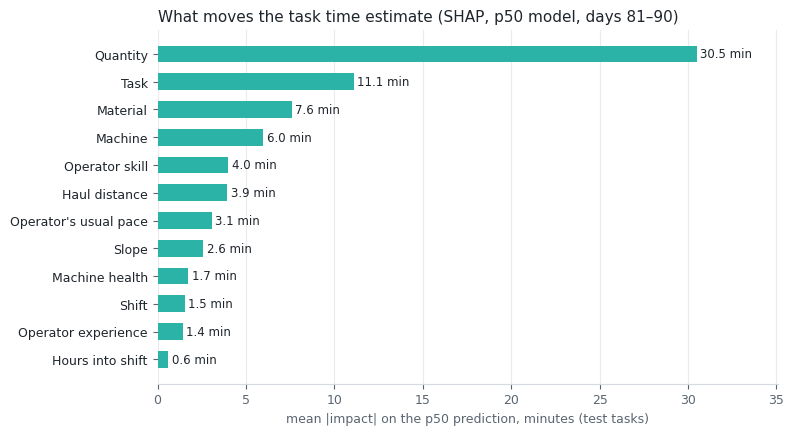

In [15]:
# design.md categorical token teal (single series, no legend); text in ink tokens
TEAL, INK, MUTED, GRID = "#2BB3A8", "#1F252C", "#5B6570", "#D5DAE0"
show = imp.iloc[:12][::-1]
labels = [T.LABELS.get(f, f.replace("_", " ").capitalize()) for f in show.index]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(range(len(show)), show.values, height=0.6, color=TEAL)
for i, v in enumerate(show.values):
    ax.text(v + 0.2, i, f"{v:.1f} min", va="center", fontsize=8.5, color=INK)
ax.set_xlabel("mean |impact| on the p50 prediction, minutes (test tasks)", color=MUTED, fontsize=9)
ax.grid(axis="x", color=GRID, alpha=0.5); ax.set_axisbelow(True)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID); ax.tick_params(colors=MUTED, labelsize=9)
ax.set_yticks(range(len(labels)), labels, color=INK)
ax.set_xlim(0, show.max() * 1.15)
ax.set_title("What moves the task time estimate (SHAP, p50 model, days 81–90)",
             fontsize=11, color=INK, loc="left")
fig.savefig(ART / "shap_importance.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [16]:
# Per-task explanation as the app shows it
idx = [0, 40, 120, 300, 500]
ex = T.predict_task_time(parts["test"][T.INPUT_COLUMNS].iloc[idx])
for p, act in zip(ex, actual["test"][idx]):
    f = ", ".join(f"{x['label']} {x['impact_min']:+.1f} min" for x in p["factors"])
    print(f"{p['task_id']}: p50 {p['p50_min']} [{p['p10_min']}-{p['p90_min']}], actual {act:.1f} | {f} | "
          f"usual {p['operator_avg_min']} min, efficiency {p['expected_efficiency']}")
print(json.dumps(ex[0], indent=2))

T-SH-2026-08-20-M01-D-1: p50 42.7 [39.8-61.8], actual 42.6 | Task: dig -4.3 min, Operator's usual pace -2.9 min, Operator skill -2.6 min | usual 39.3 min, efficiency 1.09
T-SH-2026-08-20-M07-D-4: p50 33.6 [31.6-54.2], actual 35.3 | Task: dig -3.3 min, Haul distance -2.7 min, Slope -1.7 min | usual 40.7 min, efficiency 0.83
T-SH-2026-08-21-M08-D-3: p50 39.4 [33.5-63.1], actual 39.1 | Material: rock +6.8 min, Task: dig -4.8 min, Haul distance -2.9 min | usual 36.5 min, efficiency 1.08
T-SH-2026-08-24-M01-N-1: p50 109.5 [79.3-134.1], actual 93.6 | Task: trench +31.4 min, Material: sand -13.4 min, Machine: excavator +5.4 min | usual 105.1 min, efficiency 1.04
T-SH-2026-08-26-M12-D-3: p50 94.1 [65.8-140.6], actual 73.7 | Haul distance +33.9 min, Task: haul +21.2 min, Operator skill -6.7 min | usual 95.3 min, efficiency 0.99
{
  "task_id": "T-SH-2026-08-20-M01-D-1",
  "p10_min": 39.8,
  "p50_min": 42.7,
  "p90_min": 61.8,
  "factors": [
    {
      "feature": "task_type=dig",
      "label": 

## 7 — Did the model recover the planted factors?

Counterfactual test: take every test task, set one factor to value A and then B (all else
unchanged), and compare the median p50 ratio B/A with the multiplier in the generator's hidden
formula (`docs/synthetic_data.md`). Pass = right direction and within ±50 % of the planted
effect in log terms. Rain, skill and night are also tested with their correlated features moved
the way they move in the data. The model can split the credit: visibility drops to 1.5–4 km
only when rain > 5 mm, `operator_avg_time_ratio` carries skill, and usual fatigue is higher on
night shifts.

In [17]:
base_X = X["test"].copy()

def p50(Xc):
    return np.expm1(models[0.5].predict(Xc))

def ratio(set_a, set_b):
    a, b = base_X.copy(), base_X.copy()
    set_a(a); set_b(b)
    return float(np.median(p50(b) / p50(a)))

def setter(**kv):
    def f(Z):
        for k, v in kv.items():
            Z[k] = pd.Categorical([v] * len(Z), categories=categories[k]) if k in CATEGORICAL else v
    return f

f_skill = lambda s: 1.25 - 0.5 * s
def skill_setter(s, move_ratio):
    exp_years = (s - 0.3) / 0.035              # generator: skill ~ 0.3 + 0.035 * experience
    def f(Z):
        Z["skill_score"] = s
        Z["experience_years"] = exp_years
        Z["certification_level"] = 1 if exp_years < 3 else 2 if exp_years < 8 else 3
        if move_ratio:
            Z["operator_avg_time_ratio"] = (base_X.operator_avg_time_ratio
                                            * f_skill(s) / f_skill(base_X.skill_score))
    return f

trn = parts["train"]
fat_day = float(trn.loc[trn.shift_type == "day", "operator_fatigue_hour_avg"].mean())
fat_night = float(trn.loc[trn.shift_type == "night", "operator_fatigue_hour_avg"].mean())
checks = [
    ("Rain 0 → 10 mm", setter(rain_mm=0.0), setter(rain_mm=10.0), 1 + 0.015 * 10),
    ("Rain 0 → 10 mm (+ visibility 8000 → 2750 m)", setter(rain_mm=0.0, visibility_m=8000.0),
     setter(rain_mm=10.0, visibility_m=2750.0), 1 + 0.015 * 10),
    ("Material clay → rock", setter(material_type="clay"), setter(material_type="rock"), 1.4),
    ("Material clay → sand", setter(material_type="clay"), setter(material_type="sand"), 0.9),
    ("Slope 0 → 8°", setter(terrain_slope_deg=0.0), setter(terrain_slope_deg=8.0), 1 + 0.02 * 8),
    ("Skill 0.9 → 0.45 (skill only)", skill_setter(0.9, False), skill_setter(0.45, False),
     f_skill(0.45) / f_skill(0.9)),
    ("Skill 0.9 → 0.45 (+ usual pace)", skill_setter(0.9, True), skill_setter(0.45, True),
     f_skill(0.45) / f_skill(0.9)),
    ("Day → night shift", setter(shift_type="day"), setter(shift_type="night"), 1.10),
    ("Day → night shift (+ usual fatigue)", setter(shift_type="day", operator_fatigue_hour_avg=fat_day),
     setter(shift_type="night", operator_fatigue_hour_avg=fat_night), 1.10),
    ("Hours into shift 3 → 7.5", setter(hours_into_shift=3.0), setter(hours_into_shift=7.5),
     1 + 0.02 * 1.5),
]
rows = []
for name, a, b, planted in checks:
    got = ratio(a, b)
    ok = (np.sign(np.log(got)) == np.sign(np.log(planted))
          and abs(np.log(got) - np.log(planted)) <= 0.5 * abs(np.log(planted)))
    rows.append({"factor": name, "planted_x": round(planted, 3), "recovered_x": round(got, 3),
                 "recovered": bool(ok)})
planted_check = pd.DataFrame(rows)
# One verdict per planted factor: recovered if any of its variants passes
planted_check["group"] = planted_check.factor.str.split().str[0].replace({"Day": "Night", "Hours": "Hours into shift"})
by_factor = planted_check.groupby("group", sort=False).recovered.any()
print(by_factor.to_dict())
planted_check

{'Rain': True, 'Material': True, 'Slope': True, 'Skill': True, 'Night': False, 'Hours into shift': False}


,factor,planted_x,recovered_x,recovered,group
0,Rain 0 → 10 mm,1.150,1.072,False,Rain
1,Rain 0 → 10 mm (+ visibility 8000 → 2750 m),1.150,1.113,True,Rain
2,Material clay → rock,1.400,1.287,True,Material
3,Material clay → sand,0.900,0.927,True,Material
4,Slope 0 → 8°,1.160,1.112,True,Slope
5,Skill 0.9 → 0.45 (skill only),1.281,1.185,True,Skill
6,Skill 0.9 → 0.45 (+ usual pace),1.281,1.245,True,Skill
7,Day → night shift,1.100,1.048,False,Night
8,Day → night shift (+ usual fatigue),1.100,1.040,False,Night
9,Hours into shift 3 → 7.5,1.030,0.936,False,Hours into shift


**Why hours into shift (and, more weakly, night) fail: survivorship.** A task still running at shift
end is `delayed` with no duration, so it can't be a training target. Late in the shift only the
short tasks finish, so the completed late tasks the model sees are biased short. The planted +2 %/h
after hour 6 is invisible under that selection. Night tasks are slower, so more of them are cut off
(11.4 % vs 8.0 % by day), which halves the visible night effect. In the app, late-shift and night p50s
are therefore optimistic. A fix would need censored-duration training (e.g. treat delayed tasks as
"at least this long"), which is out of scope here.

In [18]:
nc = tasks[tasks.status != "cancelled"].merge(shifts[["shift_id", "start_time", "shift_type"]], on="shift_id")
nc["hours_into_shift"] = (nc.scheduled_start - nc.start_time).dt.total_seconds() / 3600
nc.groupby(pd.cut(nc.hours_into_shift, [0, 2, 4, 6, 7, 9]), observed=True).agg(
    tasks=("task_id", "size"), share_delayed_no_duration=("status", lambda x: (x == "delayed").mean()),
    median_completed_min=("actual_duration_min", "median")).round(3)

,tasks,share_delayed_no_duration,median_completed_min
hours_into_shift,,,
"(0, 2]",2446,0.005,84.60
"(2, 4]",1800,0.003,86.90
"(4, 6]",1747,0.048,82.65
"(6, 7]",681,0.373,59.00
"(7, 9]",339,0.820,31.00


In [19]:
nc.groupby("shift_type").status.apply(lambda x: (x == "delayed").mean()).rename("share_delayed_no_duration").round(3)

shift_type
day      0.080
night    0.114
Name: share_delayed_no_duration, dtype: float64

## 8 — Metrics and result sheet

In [20]:
import sklearn
metrics = {
    "model_name": "task_time", "version": "v1",
    "versions": {"lightgbm": lgb.__version__, "shap": shap.__version__, "sklearn": sklearn.__version__,
                 "numpy": np.__version__, "pandas": pd.__version__},
    "split": {"train_days": [1, 70], "val_days": [71, 80], "test_days": [81, 90], "by": "task_date"},
    "rows": {s: len(y[s]) for s in y},
    "target": "log1p(actual_duration_min)", "params": LGBM_PARAMS,
    "best_iteration": {str(k): v for k, v in best_iter.items()},
    "baseline": {"definition": "median(actual_duration_min / quantity) per task_type on train x quantity",
                 **baseline_scores},
    "uncalibrated": uncal, "calibrated": cal, "interval_offset_log": offset,
    "target_coverage": TARGET_COVERAGE,
    "shap_mean_abs_impact_min_test": imp.round(3).to_dict(),
    "planted_factors": rows, "planted_factors_recovered": by_factor.to_dict(),
}
(ART / "metrics.json").write_text(json.dumps(metrics, indent=2, default=float))
sizes = {p.name: p.stat().st_size for p in ART.iterdir()}
print(f"total {sum(sizes.values()) / 1e6:.2f} MB")
sizes

total 1.77 MB


{'config.json': 749,
 'encoders.json': 1129,
 'feature_list.json': 414,
 'lgbm_p10.joblib': 392892,
 'lgbm_p50.joblib': 644203,
 'lgbm_p90.joblib': 650223,
 'metrics.json': 5513,
 'README.md': 5846,
 'shap_importance.png': 64509}

In [21]:
t, bt, u = cal["test"], baseline_scores["test"], uncal["test"]
mape_d, mape_nd = (np.mean(np.abs(q[m_, 1] - a_[m_]) / a_[m_]) * 100 for m_ in (d, ~d))
cov_d, cov_nd = (np.mean((a_[m_] >= q[m_, 0]) & (a_[m_] <= q[m_, 2])) for m_ in (d, ~d))
pc_md = "\n".join(f"| {r['factor']} | ×{r['planted_x']:.3f} | ×{r['recovered_x']:.3f} | "
                  f"{'✓' if r['recovered'] else '✗'} |" for r in rows)
top = ", ".join(f"{T.LABELS.get(f, f)} {v:.1f}" for f, v in imp.iloc[:6].items())
n_ok, n_f = int(by_factor.sum()), len(by_factor)
missed = ", ".join(by_factor.index[~by_factor].str.lower())
shares = [np.log(r["recovered_x"]) / np.log(r["planted_x"]) for r in rows if r["recovered"]]
share_lo, share_hi = min(shares), max(shares)
readme = f'''# Task time estimation v1 — result sheet

Three LightGBM quantile models (p10 / p50 / p90) on `log1p(actual_duration_min)`, with SHAP
factors in minutes. Trained on days 1–70 ({len(y["train"]):,} completed tasks), early stopping and
interval calibration on days 71–80 ({len(y["val"]):,}), tested once on days 81–90 ({len(y["test"]):,}).
Notebook: `ml/02_task_time.ipynb`. Inference: `ml/inference/task_time.py` → `predict_task_time(df)`.

**In plain words:** The p50 estimate is off by {t["mae_min"]:.1f} min on average ({t["mape_pct"]:.1f} %),
against {bt["mae_min"]:.1f} min ({bt["mape_pct"]:.1f} %) for the simple "median minutes per unit × quantity"
rule. The p10–p90 range holds the real duration for {t["coverage_p10_p90"]:.0%} of test tasks (target ≈ 80 %)
after one calibration step. Without it the range was too narrow ({u["coverage_p10_p90"]:.0%}). The
model recovered {n_ok} of {n_f} planted factors from the generator's hidden formula (missed: {missed}).

![SHAP importance](shap_importance.png)

| Test, days 81–90 | MAE (min) | MAPE | p10–p90 coverage |
|---|---|---|---|
| Baseline (median min/unit per task_type × quantity) | {bt["mae_min"]:.1f} | {bt["mape_pct"]:.1f} % | — |
| p50 model, raw intervals | {t["mae_min"]:.1f} | {t["mape_pct"]:.1f} % | {u["coverage_p10_p90"]:.1%} ✗ |
| **p50 model, calibrated intervals (ships)** | **{t["mae_min"]:.1f}** ✓ | **{t["mape_pct"]:.1f} %** ✓ | **{t["coverage_p10_p90"]:.1%}** |

Calibrated test intervals: {t["below_p10"]:.1%} of tasks below p10, {t["above_p90"]:.1%} above p90,
median width {t["median_width_min"]:.1f} min. The {int(d.sum())} test tasks with a random +15–60 min delay
(waiting for truck, blocked access, refuelling) are the main misses: MAPE {mape_d:.0f} %, coverage
{cov_d:.0%}. Nothing in the features can predict them. On the other tasks MAPE is {mape_nd:.1f} %, coverage {cov_nd:.0%}.

## Why the raw intervals were too narrow, and the one tuning round
Raw coverage was {uncal["train"]["coverage_p10_p90"]:.0%} on train but {uncal["val"]["coverage_p10_p90"]:.0%}
on validation and {u["coverage_p10_p90"]:.0%} on test, with misses on both sides ({u["below_p10"]:.0%} below p10,
{u["above_p90"]:.0%} above p90). The quantile models learn the spread of the training residuals. On new
days the p50 error is larger: the operator's hidden pace is only partly known from past tasks, and the
failure-drift part of machine health is not in the logs. The random delays don't explain it.
**Fix (conformalized quantile regression):** the model parameters are unchanged. The conformity score
`max(p10 − y, y − p90)` on validation gives a log-space offset c = {offset:.3f}, so p10 is divided
and p90 multiplied by ×{np.exp(offset):.3f}. Test was not used to choose c.

## Planted factors (counterfactual on every test task, median p50 ratio)
| Change | Planted | Recovered | Pass (direction, ±50 % of log effect) |
|---|---|---|---|
{pc_md}

Mean |SHAP impact| on test (min): {top}.

**Hours into shift and night are not recovered, because of survivorship in the data.** A task still running at
shift end is `delayed` with no duration, so it can't be a target: 37 % of tasks starting in hour 6–7 and 82 % of
those starting after hour 7, and 11.4 % of night-shift tasks vs 8.0 % of day-shift tasks. The ones that are lost
are the long ones (median completed duration 31 min after hour 7 vs ~85 min early). So the model learns "late
tasks are short" (×{rows[-1]["recovered_x"]:.2f} instead of ×1.03), and sees the night effect at about half
strength (right direction). **Late-shift and night p50s are optimistic.** Fixing this needs censored-duration training
(delayed tasks as "at least this long"), which is out of scope for v1.
Rain, material, slope and skill have the right sign and {share_lo:.0%}–{share_hi:.0%} of the planted size (log terms). Rain on its own looks weak because
heavy rain (≥ 10 mm) is rare (0.5 % of hours) and visibility drops exactly when rain > 5 mm, so the model credits
both. Moving them together recovers ×{rows[1]["recovered_x"]:.2f} of ×1.15.

## Method notes
- Features as in models.md §2, plus `operator_fatigue_hour_avg` (operator's mean fatigue score
  in that hour of shift over earlier shifts). `operator_avg_time_ratio` = mean actual ÷ reference
  over the operator's same-type tasks that ended before this task's scheduled start, last 30 days
  (brute-force checked on 300 tasks, no leakage).
- `health_score` is the service-based health rebuilt from `maintenance_log`. The live backend passes
  the `health_score` from `v_machine_health_latest`.
- Targets: `completed` tasks with a duration. `delayed` tasks in this data have no duration (still
  running at shift end), so they drop out. Completed tasks with a random delay are kept.
- `personality` and `data/output/truth/` are never read. Categoricals use the training levels
  (`encoders.json`); an unseen level becomes NaN.
- Reference minutes = median minutes per unit per task_type on train, with haul measured in ton-km
  (haul time scales with distance). The evaluation baseline stays literal (per unit, no distance).
- Output: `operator_avg_min` = usual pace × reference minutes for the task (null without history);
  `expected_efficiency` = p50 ÷ operator_avg_min (< 1 = faster than their usual). Factors exclude
  `quantity`/`unit` (size of the job). Each factor carries `feature`, `label` and `impact_min`.
- Artifacts: `lgbm_p10/p50/p90.joblib` (compress=3), `encoders.json`, `config.json`
  (interval offset), `feature_list.json`, `metrics.json`. They load only with the versions pinned in
  `ml/requirements.txt`. Not yet logged to `model_runs`; `metrics.json` has the fields that table needs.
'''
(ART / "README.md").write_text(readme, encoding="utf-8")
print(readme)

# Task time estimation v1 — result sheet

Three LightGBM quantile models (p10 / p50 / p90) on `log1p(actual_duration_min)`, with SHAP
factors in minutes. Trained on days 1–70 (4,946 completed tasks), early stopping and
interval calibration on days 71–80 (717), tested once on days 81–90 (716).
Notebook: `ml/02_task_time.ipynb`. Inference: `ml/inference/task_time.py` → `predict_task_time(df)`.

**In plain words:** The p50 estimate is off by 8.9 min on average (10.6 %),
against 23.8 min (28.4 %) for the simple "median minutes per unit × quantity"
rule. The p10–p90 range holds the real duration for 80% of test tasks (target ≈ 80 %)
after one calibration step. Without it the range was too narrow (66%). The
model recovered 4 of 6 planted factors from the generator's hidden formula (missed: night, hours into shift).

![SHAP importance](shap_importance.png)

| Test, days 81–90 | MAE (min) | MAPE | p10–p90 coverage |
|---|---|---|---|
| Baseline (median min/unit per task_type × quantity) | 23.8